# Transformer Summarizer — Data Preparation

## Setup

In [41]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [42]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import sentencepiece as spm
from colorama import Fore, Style
from datasets import load_dataset
from dotenv import load_dotenv
from torch.utils.data import DataLoader

from dl_roadmap.chapters.summarization import (
    SummarizationDataset,
    deduplicate_split,
    prepare_gazeta,
)
from dl_roadmap.chapters.summarization.dataset import make_collate_fn
from dl_roadmap.data import BucketBatchSampler
from dl_roadmap.utils import (
    LoggerConfig,
    seed_everything,
    setup_logger,
)

In [43]:
%matplotlib inline

pd.set_option("display.width", 150)
pd.set_option("display.max_rows", 100)
pd.set_option("display.max_columns", None)

load_dotenv()
seed_everything()
setup_logger(LoggerConfig(log_level="WARNING"))

In [44]:
PROJECT_NAME = "10_summarizer"
SEED = 42

DATA_DIR = Path("../data")
MODEL_DIR = Path("../models") / PROJECT_NAME
RAW_DATA_DIR = DATA_DIR / "raw" / PROJECT_NAME
PROCESSED_DATA_DIR = DATA_DIR / "processed" / PROJECT_NAME
TOKENIZER_DIR = MODEL_DIR / "tokenizer"

DIRECTORIES = (
    RAW_DATA_DIR,
    PROCESSED_DATA_DIR,
    MODEL_DIR,
    TOKENIZER_DIR,
)

for directory in DIRECTORIES:
    directory.mkdir(parents=True, exist_ok=True)

## Dataset

In [45]:
dataset = load_dataset("IlyaGusev/gazeta", cache_dir=RAW_DATA_DIR)

train_df = dataset["train"].shuffle(seed=SEED).to_pandas()
val_df = dataset["validation"].to_pandas()
test_df = dataset["test"].to_pandas()

splits = {"train": train_df, "validation": val_df, "test": test_df}

### Raw data overview

In [46]:
print(f"{Fore.MAGENTA}DataFrame Info:{Style.RESET_ALL}")
for name, df in splits.items():
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    df.info()

DataFrame Info:

====== train ======
<class 'pandas.DataFrame'>
RangeIndex: 60964 entries, 0 to 60963
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     60964 non-null  str  
 1   summary  60964 non-null  str  
 2   title    60964 non-null  str  
 3   date     60964 non-null  str  
 4   url      60964 non-null  str  
dtypes: str(5)
memory usage: 522.9 MB

====== validation ======
<class 'pandas.DataFrame'>
RangeIndex: 6369 entries, 0 to 6368
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   text     6369 non-null   str  
 1   summary  6369 non-null   str  
 2   title    6369 non-null   str  
 3   date     6369 non-null   str  
 4   url      6369 non-null   str  
dtypes: str(5)
memory usage: 53.3 MB

====== test ======
<class 'pandas.DataFrame'>
RangeIndex: 6793 entries, 0 to 6792
Data columns (total 5 columns):
 #   Column   Non-Null Count  Dtype
---  ------   -

In [47]:
print(f"{Fore.YELLOW}First Rows of DataFrame:{Style.RESET_ALL}")
for name, df in splits.items():
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    print(df.head())

First Rows of DataFrame:

====== train ======
                                                text                                            summary                                   title  \
0  В сети появилось видео задержания 58-летнего в...  Департамент транспорта Москвы проведет внеплан...  «Мы проведем тщательное расследование»   
1  В преддверии первого матча раунда плей-офф Лиг...  Накануне матча с «Рубином» главный тренер «Лио...          «Рубин» не боимся, но уважаем»   
2  Mail.ru Group , владеющая 39,99% «ВКонтакте», ...  Павел Дуров получит операционный контроль над ...               «ВКонтакте» под контролем   
3  Американский сенатор Джон Маккейн отреагировал...  Сенатор-республиканец Джон Маккейн молится за ...      Танкер протаранил «Джона Маккейна»   
4  Во вторник норвежский Нобелевский комитет расп...  Вручение Нобелевской премии мира спровоцировал...                Нобелевская премия войны   

                  date                                                u

In [48]:
print(f"{Fore.RED}Missing Values in Each Column:{Style.RESET_ALL}")
for name, df in splits.items():
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    missing = df.isnull().sum()
    missing_percent = (missing / len(df)) * 100
    missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_percent})
    print(missing_df)

Missing Values in Each Column:

====== train ======
         Missing Count  Missing %
text                 0        0.0
summary              0        0.0
title                0        0.0
date                 0        0.0
url                  0        0.0

====== validation ======
         Missing Count  Missing %
text                 0        0.0
summary              0        0.0
title                0        0.0
date                 0        0.0
url                  0        0.0

====== test ======
         Missing Count  Missing %
text                 0        0.0
summary              0        0.0
title                0        0.0
date                 0        0.0
url                  0        0.0


### Cleaning

In [ ]:
train_df = prepare_gazeta(train_df, cache_file=PROCESSED_DATA_DIR / "train_df.csv")
val_df = prepare_gazeta(val_df, cache_file=PROCESSED_DATA_DIR / "val_df.csv")
test_df = prepare_gazeta(test_df, cache_file=PROCESSED_DATA_DIR / "test_df.csv")

seen_articles: set[str] = set()
seen_summaries: set[str] = set()

train_df, train_duplicates = deduplicate_split(train_df, seen_articles, seen_summaries)
val_df, val_duplicates = deduplicate_split(val_df, seen_articles, seen_summaries)
test_df, test_duplicates = deduplicate_split(test_df, seen_articles, seen_summaries)

splits = {"train": train_df, "validation": val_df, "test": test_df}

print(
    f"{Fore.RED}Removed duplicates:{Style.RESET_ALL} "
    f"train={train_duplicates:,}, validation={val_duplicates:,}, "
    f"test={test_duplicates:,}"
)

Removed duplicates: train=1, validation=0, test=0


In [50]:
print(f"{Fore.YELLOW}First Rows of DataFrame:{Style.RESET_ALL}")
for name, df in splits.items():
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    print(df.head())

First Rows of DataFrame:

====== train ======
                                                text                                            summary
0  В сети появилось видео задержания 58-летнего в...  Департамент транспорта Москвы проведет внеплан...
1  В преддверии первого матча раунда плей-офф Лиг...  Накануне матча с «Рубином» главный тренер «Лио...
2  Mail.ru Group , владеющая 39,99% «ВКонтакте», ...  Павел Дуров получит операционный контроль над ...
3  Американский сенатор Джон Маккейн отреагировал...  Сенатор-республиканец Джон Маккейн молится за ...
4  Во вторник норвежский Нобелевский комитет расп...  Вручение Нобелевской премии мира спровоцировал...

====== validation ======
                                                text                                            summary
0  В 2020 году инфляция в России составит 3,5-4%,...  В уходящем году инфляция в России находится на...
1  Глава Белого дома Дональд Трамп выразил надежд...  Мировая общественность призвала лидера КНД

### SentencePiece

In [51]:
force_tokenizer_train = False

if force_tokenizer_train or not (TOKENIZER_DIR / "sp.model").is_file():
    data_path = PROCESSED_DATA_DIR / "data.txt"
    data_path.write_text("\n".join(train_df["text"]), encoding="utf-8")
    spm.SentencePieceTrainer.train(
        input=str(data_path),
        model_prefix=str(TOKENIZER_DIR / "sp"),
        vocab_size=32000,
        model_type="unigram",
        character_coverage=1.0,
        byte_fallback=True,
        max_sentence_length=16384,
        num_threads=os.cpu_count() or 4,
        pad_id=3,
        unk_id=2,
        bos_id=0,
        eos_id=1,
        pad_piece="<PAD>",
        unk_piece="<UNK>",
        bos_piece="<BOS>",
        eos_piece="<EOS>",
    )

sp = spm.SentencePieceProcessor(model_file=str(TOKENIZER_DIR / "sp.model"))

### Token length analysis

In [52]:
for df in splits.values():
    df["article_length"] = [
        len(token_ids) for token_ids in sp.encode(df["text"].tolist(), out_type=int)
    ]
    df["summary_length"] = [
        len(token_ids) for token_ids in sp.encode(df["summary"].tolist(), out_type=int)
    ]
    df["summary_article_ratio"] = df["summary_length"] / df["article_length"]

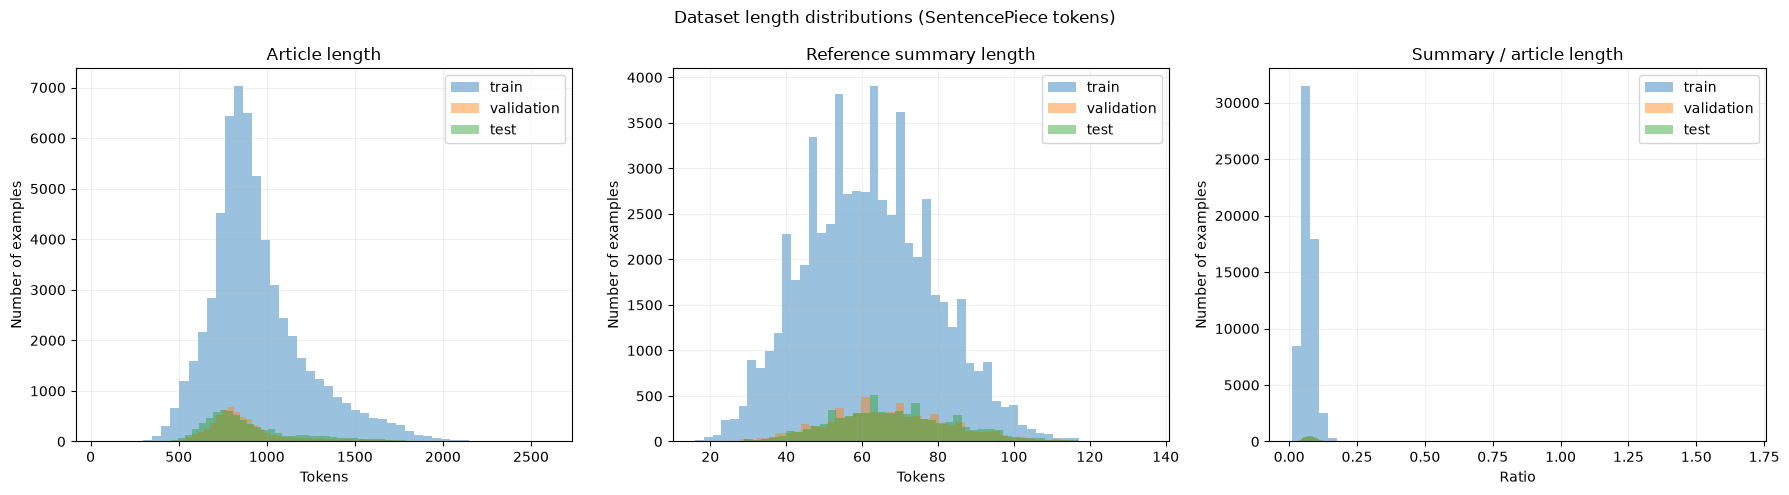

In [53]:
plot_specs = (
    ("article_length", "Article length", "Tokens"),
    ("summary_length", "Reference summary length", "Tokens"),
    ("summary_article_ratio", "Summary / article length", "Ratio"),
)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (column, title, xlabel) in zip(axes, plot_specs, strict=True):
    for split_name, df in splits.items():
        ax.hist(df[column], bins=50, alpha=0.45, label=split_name)

    ax.set(title=title, xlabel=xlabel, ylabel="Number of examples")
    ax.grid(alpha=0.2)
    ax.legend()

fig.suptitle("Dataset length distributions (SentencePiece tokens)")
fig.tight_layout()
plt.show()

### Length filtering

In [54]:
MAX_ARTICLE_LENGTH = 1280
MAX_SUMMARY_LENGTH = 128

print(f"{Fore.YELLOW}Article length cutoff:{Style.RESET_ALL}")
for split_name, df in splits.items():
    removed_count = (df["article_length"] > MAX_ARTICLE_LENGTH).sum()
    removed_percent = removed_count / len(df) * 100

    print(
        f"{Fore.CYAN}{split_name}:{Style.RESET_ALL} removing "
        f"{Fore.RED}{removed_count:,}{Style.RESET_ALL} of {len(df):,} examples "
        f"({Fore.YELLOW}{removed_percent:.2f}%{Style.RESET_ALL})"
    )

print(f"\n{Fore.YELLOW}Summary length cutoff:{Style.RESET_ALL}")
for split_name, df in splits.items():
    removed_count = (df["summary_length"] > MAX_SUMMARY_LENGTH).sum()
    removed_percent = removed_count / len(df) * 100

    print(
        f"{Fore.CYAN}{split_name}:{Style.RESET_ALL} removing "
        f"{Fore.RED}{removed_count:,}{Style.RESET_ALL} of {len(df):,} examples "
        f"({Fore.YELLOW}{removed_percent:.2f}%{Style.RESET_ALL})"
    )

Article length cutoff:
train: removing 7,210 of 60,750 examples (11.87%)
validation: removing 581 of 6,369 examples (9.12%)
test: removing 866 of 6,791 examples (12.75%)

Summary length cutoff:
train: removing 2 of 60,750 examples (0.00%)
validation: removing 2 of 6,369 examples (0.03%)
test: removing 0 of 6,791 examples (0.00%)


In [55]:
train_df = train_df[
    (train_df["article_length"] <= MAX_ARTICLE_LENGTH)
    & (train_df["summary_length"] <= MAX_SUMMARY_LENGTH)
].reset_index(drop=True)

val_df = val_df[
    (val_df["article_length"] <= MAX_ARTICLE_LENGTH)
    & (val_df["summary_length"] <= MAX_SUMMARY_LENGTH)
].reset_index(drop=True)

test_df = test_df[
    (test_df["article_length"] <= MAX_ARTICLE_LENGTH)
    & (test_df["summary_length"] <= MAX_SUMMARY_LENGTH)
].reset_index(drop=True)

splits = {"train": train_df, "validation": val_df, "test": test_df}

In [56]:
print(f"{Fore.MAGENTA}DataFrame Info:{Style.RESET_ALL}")
for name, df in splits.items():
    print(f"\n{Fore.CYAN}====== {name} ======{Style.RESET_ALL}")
    df.info()

DataFrame Info:

====== train ======
<class 'pandas.DataFrame'>
RangeIndex: 53538 entries, 0 to 53537
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   text                   53538 non-null  str    
 1   summary                53538 non-null  str    
 2   article_length         53538 non-null  int64  
 3   summary_length         53538 non-null  int64  
 4   summary_article_ratio  53538 non-null  float64
dtypes: float64(1), int64(2), str(2)
memory usage: 421.1 MB

====== validation ======
<class 'pandas.DataFrame'>
RangeIndex: 5787 entries, 0 to 5786
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   text                   5787 non-null   str    
 1   summary                5787 non-null   str    
 2   article_length         5787 non-null   int64  
 3   summary_length         5787 non-null   int64  
 4   summ

## PyTorch datasets and batching

### Dataset construction

In [63]:
SummarizationDataset.MAX_ARTICLE_LENGTH = MAX_ARTICLE_LENGTH
SummarizationDataset.MAX_SUMMARY_LENGTH = MAX_SUMMARY_LENGTH

In [64]:
train_dataset = SummarizationDataset(train_df, sp)
val_dataset = SummarizationDataset(val_df, sp)
test_dataset = SummarizationDataset(test_df, sp)

In [65]:
pad_id = sp.pad_id()
collate_fn = make_collate_fn(pad_id)

### Length bucketing

In [66]:
batch_size = 32

train_batch_sampler = BucketBatchSampler(
    lengths=train_dataset.df["text_ids"].str.len().tolist(),
    batch_size=batch_size,
    bucket_size_multiplier=100,
    shuffle=True,
    drop_last=True,
    seed=SEED,
)

In [67]:
train_loader = DataLoader(
    train_dataset,
    batch_sampler=train_batch_sampler,
    collate_fn=collate_fn,
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    collate_fn=collate_fn,
    drop_last=True,
)

### Bucketing sanity check

In [68]:
MAX_BATCHES_TO_DISPLAY = 10

for batch_idx, indices in enumerate(train_batch_sampler):
    lengths = [len(train_dataset.df.iloc[index]["text_ids"]) for index in indices]

    print(
        f"batch={batch_idx:02d} | "
        f"min={min(lengths):4d} | "
        f"max={max(lengths):4d} | "
        f"range={max(lengths) - min(lengths):4d} | "
        f"lengths={lengths}"
    )

    if batch_idx + 1 >= MAX_BATCHES_TO_DISPLAY:
        break

batch=00 | min= 532 | max= 551 | range=  19 | lengths=[535, 548, 547, 535, 547, 543, 546, 551, 541, 536, 546, 537, 546, 551, 541, 547, 541, 542, 543, 535, 532, 550, 541, 534, 541, 535, 547, 548, 550, 543, 539, 536]
batch=01 | min= 620 | max= 632 | range=  12 | lengths=[630, 621, 621, 621, 627, 628, 626, 626, 629, 621, 627, 620, 624, 622, 627, 623, 632, 623, 622, 621, 622, 620, 629, 627, 621, 627, 631, 623, 628, 631, 628, 632]
batch=02 | min= 877 | max= 882 | range=   5 | lengths=[878, 878, 879, 881, 880, 880, 879, 880, 878, 880, 877, 879, 879, 880, 882, 877, 881, 880, 880, 881, 878, 879, 877, 881, 880, 880, 880, 882, 878, 879, 878, 882]
batch=03 | min= 872 | max= 875 | range=   3 | lengths=[874, 873, 873, 875, 872, 874, 874, 873, 873, 873, 874, 873, 874, 872, 873, 874, 873, 875, 874, 875, 873, 873, 872, 873, 875, 875, 875, 872, 872, 874, 873, 873]
batch=04 | min= 478 | max= 509 | range=  31 | lengths=[497, 501, 509, 478, 487, 509, 493, 501, 480, 494, 492, 501, 489, 486, 490, 492, 490, 